# Spearman's Rank Correlation

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

In [2]:
df_raw = pd.read_csv('data_CBR-RAG_2026-04-06_13-14_final.csv', encoding='utf-16', sep='\t')
df_raw = df_raw.copy()
df_raw['participant_id'] = df_raw['CASE']

RAG_COLS = ['Q101','Q104','Q105','Q123','Q109','Q112','Q113','Q116',
            'Q117','Q120','Q121','Q136','Q137','Q140','Q141','Q144','Q145','Q148']

DIMENSIONS = {
    '01': 'Helpfulness',
    '02': 'Clarity',
    '03': 'Naturalness',
    '04': 'Length Appropriateness',
    '05': 'Trustworthiness',
    '06': 'Process Grounding'
}

# Cosine similarity scores recorded at retrieval time for each CBR-RAG answer
COSINE = {
    'Q101': 1.0000, 'Q104': 0.7994, 'Q105': 0.7301, 'Q123': 1.0000,
    'Q109': 0.9055, 'Q112': 0.8973, 'Q113': 1.0000, 'Q116': 0.6640,
    'Q117': 0.5853, 'Q120': 1.0000, 'Q121': 0.7452, 'Q136': 0.6063,
    'Q137': 1.0000, 'Q140': 0.6213, 'Q141': 0.6161, 'Q144': 1.0000,
    'Q145': 0.7489, 'Q148': 0.5702
}

print(f'Loaded {len(df_raw)} participants')
print(f'Questions: {len(RAG_COLS)}')

Loaded 36 participants
Questions: 18


## Mean User Score per Question


In [3]:
results = []
for col in RAG_COLS:
    dim_scores = []
    for suffix in DIMENSIONS.keys():
        full_col = f'{col}_{suffix}'
        if full_col in df_raw.columns:
            reversed_scores = 6 - df_raw[full_col]  # reverse scoring
            dim_scores.append(reversed_scores.mean())
    results.append({
        'question':        col,
        'cosine':          COSINE[col],
        'mean_user_score': round(np.mean(dim_scores), 4)
    })

df_h4 = pd.DataFrame(results)
print('Mean user score and cosine similarity per question:')
print('(mean_user_score: 1 = Strongly Disagree, 5 = Strongly Agree)')
print('=' * 50)
print(df_h4.to_string(index=False))

Mean user score and cosine similarity per question:
(mean_user_score: 1 = Strongly Disagree, 5 = Strongly Agree)
question  cosine  mean_user_score
    Q101  1.0000           3.7361
    Q104  0.7994           3.5741
    Q105  0.7301           3.3148
    Q123  1.0000           4.3287
    Q109  0.9055           4.3380
    Q112  0.8973           3.1620
    Q113  1.0000           4.2361
    Q116  0.6640           3.9954
    Q117  0.5853           3.4074
    Q120  1.0000           4.0509
    Q121  0.7452           4.0972
    Q136  0.6063           4.1019
    Q137  1.0000           3.7500
    Q140  0.6213           3.5880
    Q141  0.6161           4.1065
    Q144  1.0000           3.7963
    Q145  0.7489           3.9259
    Q148  0.5702           4.0509


## Assign Ranks and Handle Ties


In [4]:
df_h4['rank_cosine'] = df_h4['cosine'].rank(method='average')
df_h4['rank_score']  = df_h4['mean_user_score'].rank(method='average')

print(df_h4[['question','cosine','rank_cosine','mean_user_score','rank_score']].to_string(index=False))
print()

question  cosine  rank_cosine  mean_user_score  rank_score
    Q101  1.0000         15.5           3.7361         6.0
    Q104  0.7994         10.0           3.5741         4.0
    Q105  0.7301          7.0           3.3148         2.0
    Q123  1.0000         15.5           4.3287        17.0
    Q109  0.9055         12.0           4.3380        18.0
    Q112  0.8973         11.0           3.1620         1.0
    Q113  1.0000         15.5           4.2361        16.0
    Q116  0.6640          6.0           3.9954        10.0
    Q117  0.5853          2.0           3.4074         3.0
    Q120  1.0000         15.5           4.0509        11.5
    Q121  0.7452          8.0           4.0972        13.0
    Q136  0.6063          3.0           4.1019        14.0
    Q137  1.0000         15.5           3.7500         7.0
    Q140  0.6213          5.0           3.5880         5.0
    Q141  0.6161          4.0           4.1065        15.0
    Q144  1.0000         15.5           3.7963         8

## Spearman's Rank Correlation


In [5]:
rho, p_two = spearmanr(df_h4['cosine'], df_h4['mean_user_score'])

# Convert to one-sided p-value
# If rho > 0, one-sided p = two-sided p / 2
# If rho < 0, one-sided p = 1 - (two-sided p / 2)
p_one = p_two / 2 if rho > 0 else 1 - (p_two / 2)

print(f'rho (Spearmans):       {rho:.3f}')
print(f'p-value (two-sided):   {p_two:.4f}')
print(f'p-value (one-sided):   {p_one:.4f}')



rho (Spearmans):       0.129
p-value (two-sided):   0.6104
p-value (one-sided):   0.3052


C:\Users\101402\AppData\Local\Temp\ipykernel_27292\2955210705.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, frameon=False)


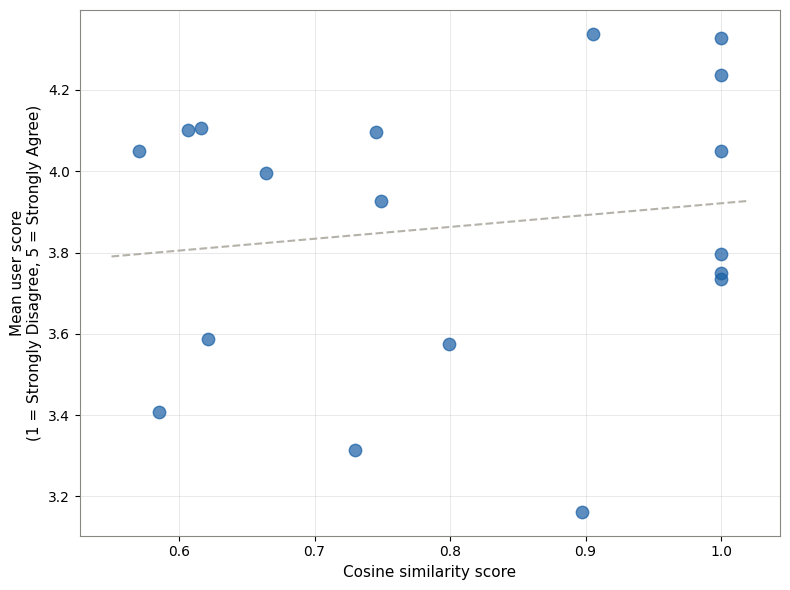

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df_h4['cosine'], df_h4['mean_user_score'],
           color='#185FA5', alpha=0.7, s=80, zorder=3)

# Add a trend line
m, b = np.polyfit(df_h4['cosine'], df_h4['mean_user_score'], 1)
x_line = np.linspace(df_h4['cosine'].min() - 0.02, df_h4['cosine'].max() + 0.02, 100)
ax.plot(x_line, m * x_line + b, color='#B4B2A9', linewidth=1.5,
        linestyle='--', zorder=2)

ax.set_xlabel('Cosine similarity score', fontsize=11)
ax.set_ylabel('Mean user score\n(1 = Strongly Disagree, 5 = Strongly Agree)', fontsize=11)

ax.legend(fontsize=10, frameon=False)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color('#888780')

ax.grid(axis='both', linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.savefig('h4_scatterplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
df_h4.to_csv('h4_spearman_results.csv', index=False)